# 01: Core Workflow, from Question to Refutation

We work through the central DoWhy workflow in a slow, explicit way. We will start with a causal question, create a small observational dataset where the true effect is known, draw the causal graph, identify the estimand, estimate the effect, and then try to refute the estimate.

The goal is for students to understand what each DoWhy step is doing conceptually. The code matters, but the causal reasoning matters more.


## Learning Goals

By the end, you should be able to:

- Explain the difference between a causal question, a causal graph, an estimand, an estimator, and a refuter.
- Build a `dowhy.CausalModel` from a pandas dataframe and a graph.
- Use `identify_effect()` to inspect the causal estimand before estimating anything.
- Use `estimate_effect()` with a simple backdoor estimator.
- Use `refute_estimate()` to run basic robustness checks.
- Write a clear, cautious summary of a causal result.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use mostly simulated or semi-synthetic observational datasets to study **Core Workflow, From Question To Refutation**. DoWhy is mainly about causal modeling discipline: graph, estimand, estimator, and refuter. A controlled dataset lets us show how a change in assumptions changes the estimand and the credibility of the estimate.

Read each row as an observed unit in a business or policy system. The treatment, outcome, common causes, instruments, mediators, and anomaly indicators are named to mirror applied causal workflows and keep the examples close to realistic analysis language. The experiment follows a single treatment-to-outcome workflow so the reader can track how modeling, identification, estimation, and refutation fit together.

The simulation is designed to make the identifying assumptions and diagnostic checks visible. It is meant to expose the assumptions that would be hidden in real data, where the true counterfactual outcome is unavailable.


## Mathematical Foundation

<!-- math-foundation-note -->

DoWhy separates a causal workflow into estimand, identification, estimation, and refutation. The central estimand in many tutorials is

$$
\tau=\mathbb{E}\{Y(1)-Y(0)\}.
$$

Identification turns that counterfactual object into an observed-data expression. Estimation computes it from data. Refutation checks whether the conclusion is stable under changes that should not create a causal effect.


## The Core DoWhy Pattern

Most classical DoWhy effect-estimation analyses follow this pattern:

1. **Model** the problem with data, treatment, outcome, and a causal graph.
2. **Identify** the causal estimand implied by the graph.
3. **Estimate** the identified estimand using a statistical estimator.
4. **Refute** the estimate using diagnostic stress tests.

A common beginner mistake is jumping directly to estimation. DoWhy is designed to slow that down. It asks you to make the causal assumptions explicit before computing a number.





## Tutorial Workflow

#### Setup

This setup block imports the packages used in this lesson, creates output folders, fixes a random seed, and suppresses known third-party compatibility warnings. The warning policy is narrow: it keeps student-facing analysis output focused on the causal workflow while leaving real execution errors visible.


In [ ]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import importlib.metadata as metadata
import os
import platform
import sys
import warnings
# Find the repository root from either the repo root or the notebook folder.
START_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in [START_DIR, *START_DIR.parents] if (candidate / "pyproject.toml").exists()),
    START_DIR,
)
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "dowhy"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
CACHE_DIR = PROJECT_ROOT / ".cache" / "matplotlib"
for directory in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR))
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*setParseAction.*deprecated.*")
warnings.filterwarnings("ignore", message=".*copy keyword is deprecated.*")
warnings.filterwarnings("ignore", message=".*disp.*iprint.*L-BFGS-B.*")
warnings.filterwarnings("ignore", module="dowhy.causal_estimators.regression_estimator")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", module="seaborn.categorical")
warnings.filterwarnings("ignore", module="pydot.dot_parser")
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
# Compatibility shim for DoWhy estimators written against older pandas Series integer indexing.
if not getattr(pd.Series, "_dowhy_integer_position_patch", False):
    _original_series_getitem = pd.Series.__getitem__
    def _dowhy_series_getitem_compat(self, key):
        try:
            return _original_series_getitem(self, key)
        except KeyError:
            if isinstance(key, int) and key not in self.index:
                return self.iloc[key]
            raise
    pd.Series.__getitem__ = _dowhy_series_getitem_compat
    pd.Series._dowhy_integer_position_patch = True
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
# Compatibility shim for DoWhy versions that expect the older NetworkX d_separated API.
if not hasattr(nx.algorithms, "d_separated"):
    from networkx.algorithms.d_separation import is_d_separator
    nx.algorithms.d_separated = is_d_separator
import statsmodels.formula.api as smf
import dowhy
from dowhy import CausalModel
RANDOM_SEED = 7
rng = np.random.default_rng(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")
print(f"Python executable: {sys.executable}")
print(f"Python version: {platform.python_version()}")
print(f"DoWhy version: {getattr(dowhy, '__version__', 'unknown')}")
print(f"Notebook directory: {NOTEBOOK_DIR}")


If this step prints a DoWhy version, the lesson is ready to run. The output folders are shared across the DoWhy tutorial series, and this lesson writes files with a `01_` prefix.


### The Causal Question

We need a concrete question before we create any model. In this worked example, imagine a product team wants to know whether showing a helpful feature exposure increases next-week user value.

The causal question is:

> What is the average causal effect of `feature_exposure` on `weekly_value`?

This is phrased as an intervention question. We are asking whether exposed users have higher value. We are asking what would happen if similar users were exposed versus not exposed.


#### Variable Roles

A causal workflow should name the role of each variable before modeling. The code below creates a compact design table that will guide the rest of the lesson.


| role | variable | meaning | timing |
| --- | --- | --- | --- |
| Treatment | feature_exposure | Binary indicator for whether the user received the feature exposure. | Assigned after baseline covariates are observed. |
| Outcome | weekly_value | User value measured in the following week. | Measured after treatment assignment. |
| Observed common cause | user_engagement | Baseline engagement tendency that affects both exposure assignment and future value. | Pre-treatment. |
| Observed common cause | prior_activity | Baseline activity count that affects both exposure assignment and future value. | Pre-treatment. |
| Observed common cause | is_power_segment | Pre-treatment segment flag that affects assignment and future value. | Pre-treatment. |
| Observed common cause | account_age_weeks | Pre-treatment account age that affects assignment and future value. | Pre-treatment. |


This table is part of the design record. It is part of the causal design. If a variable is measured after treatment, it usually should not be casually dropped into a backdoor adjustment set. Here all common causes are pre-treatment, which makes the worked example clean.


#### Create an Example Dataset

We will simulate observational data where the true causal effect is known. This is useful for learning because we can compare the naive association, the adjusted estimate, and the known data-generating effect.

The treatment is not randomized. Users with higher engagement, activity, power-segment status, and account age are more likely to receive the exposure. Those same variables also affect the outcome, which creates confounding.


In [2]:
# Define reusable helpers for the Create An Example Dataset section.
def make_core_workflow_data(n=3_000, seed=7):
    """
    Idea: Construct the core workflow data used in the Create An Example Dataset section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    n : int
        Number of observations or repetitions to generate.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    tuple
        Tuple containing df, true_ate.
    """
    local_rng = np.random.default_rng(seed)
    user_engagement = local_rng.normal(loc=0.0, scale=1.0, size=n)
    prior_activity = np.clip(
        local_rng.poisson(lam=np.exp(1.0 + 0.25 * user_engagement), size=n),
        0,
        25,
    )
    account_age_weeks = local_rng.gamma(shape=2.2, scale=3.0, size=n)
    is_power_segment = local_rng.binomial(
        n=1,
        p=1 / (1 + np.exp(-(0.75 * user_engagement - 0.20))),
        size=n,
    )
    treatment_logit = (
        -0.55
        + 0.90 * user_engagement
        + 0.050 * prior_activity
        + 0.50 * is_power_segment
        + 0.025 * account_age_weeks
    )
    treatment_probability = 1 / (1 + np.exp(-treatment_logit))
    feature_exposure = local_rng.binomial(n=1, p=treatment_probability, size=n)
    true_ate = 2.0
    weekly_value = (
        4.0
        + true_ate * feature_exposure
        + 1.35 * user_engagement
        + 0.075 * prior_activity
        + 0.55 * is_power_segment
        + 0.035 * account_age_weeks
        + local_rng.normal(loc=0.0, scale=1.0, size=n)
    )
    df = pd.DataFrame(
        {
            "feature_exposure": feature_exposure,
            "weekly_value": weekly_value,
            "user_engagement": user_engagement,
            "prior_activity": prior_activity,
            "is_power_segment": is_power_segment,
            "account_age_weeks": account_age_weeks,
            "treatment_probability": treatment_probability,
        }
    )
    return df, true_ate
analysis_df, TRUE_ATE = make_core_workflow_data()
analysis_df.to_csv(TABLE_DIR / "01_teaching_dataset.csv", index=False)
print(f"Rows: {len(analysis_df):,}")
print(f"Known true average treatment effect: {TRUE_ATE:.2f}")
analysis_df.head()


Rows: 3,000
Known true average treatment effect: 2.00


,feature_exposure,weekly_value,user_engagement,prior_activity,is_power_segment,account_age_weeks,treatment_probability
0,0,3.024835,0.001230,2,0,0.946460,0.395266
1,0,4.851887,0.298746,1,0,2.215199,0.456175
2,0,5.810002,-0.274138,3,1,6.011149,0.500889
3,1,5.044898,-0.890592,3,1,1.259362,0.338486
4,0,5.330653,-0.454671,2,0,23.665147,0.433503


The first rows show one observation per user-like unit. The column `treatment_probability` is included only for diagnostics because we created the data ourselves. In real observational data, the true assignment probability is usually unknown.


### Basic Dataset Checks

Before building a causal model, inspect the treatment rate, outcome scale, and covariate ranges. These checks are ordinary data hygiene, but they also help catch causal-design issues such as rare treatment or limited outcome variation.


In [3]:
basic_summary = analysis_df.agg(
    {
        "feature_exposure": ["mean", "sum"],
        "weekly_value": ["mean", "std", "min", "max"],
        "user_engagement": ["mean", "std", "min", "max"],
        "prior_activity": ["mean", "std", "min", "max"],
        "is_power_segment": ["mean", "sum"],
        "account_age_weeks": ["mean", "std", "min", "max"],
        "treatment_probability": ["mean", "std", "min", "max"],
    }
).T
basic_summary.to_csv(TABLE_DIR / "01_basic_dataset_summary.csv")
basic_summary


,mean,sum,std,min,max
feature_exposure,0.477000,1431.0,NaN,NaN,NaN
weekly_value,5.606082,NaN,2.380978,-1.604907,14.234873
user_engagement,-0.031283,NaN,0.992735,-3.661082,3.148139
prior_activity,2.797667,NaN,1.829894,0.000000,11.000000
is_power_segment,0.447333,1342.0,NaN,NaN,NaN
account_age_weeks,6.655430,NaN,4.472322,0.083604,30.510374
treatment_probability,0.488685,NaN,0.216235,0.025461,0.959013


The treatment mean is the share of users who received exposure. If this value were extremely close to zero or one, we would worry that the observed data contain too little comparison information for a stable causal estimate.


### Show the Confounding Mechanism

This plot shows two reasons the raw exposed-versus-unexposed comparison is not causal. First, treatment probabilities differ across users. Second, a key pre-treatment covariate, `user_engagement`, is imbalanced between exposed and unexposed users.


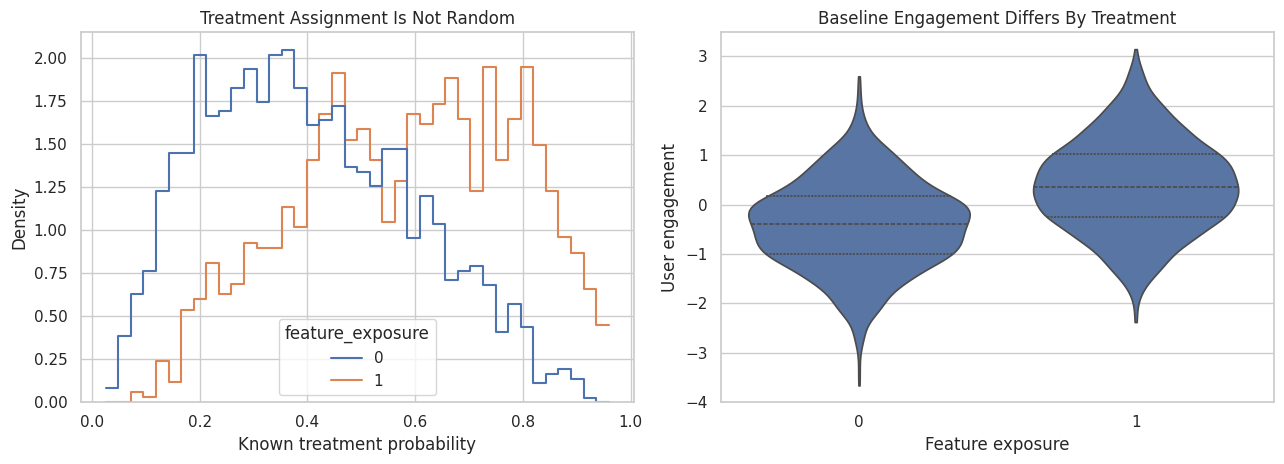

In [4]:
# Build and label the diagnostic visualization for the Show The Confounding Mechanism section.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.histplot(
    data=analysis_df,
    x="treatment_probability",
    hue="feature_exposure",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    ax=axes[0],
)
axes[0].set_title("Treatment Assignment Is Not Random")
axes[0].set_xlabel("Known treatment probability")
axes[0].set_ylabel("Density")
sns.violinplot(
    data=analysis_df,
    x="feature_exposure",
    y="user_engagement",
    inner="quartile",
    cut=0,
    ax=axes[1],
)
axes[1].set_title("Baseline Engagement Differs By Treatment")
axes[1].set_xlabel("Feature exposure")
axes[1].set_ylabel("User engagement")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "01_assignment_and_confounding_checks.png", dpi=160, bbox_inches="tight")
plt.show()


The exposed group is tilted toward users who were already more engaged. That is the practical meaning of confounding here: exposed users would have had higher outcomes even without exposure unless we adjust for the baseline variables that drove assignment.


#### Naive Association

Now compute the raw treated-minus-control difference in mean outcomes. This is a useful baseline because it shows what we would conclude if we ignored the causal design.


In [5]:
outcome_by_treatment = (
    analysis_df.groupby("feature_exposure")
    .agg(
        mean_weekly_value=("weekly_value", "mean"),
        rows=("weekly_value", "size"),
    )
    .reset_index()
)
naive_effect = (
    outcome_by_treatment.loc[outcome_by_treatment["feature_exposure"] == 1, "mean_weekly_value"].iloc[0]
    - outcome_by_treatment.loc[outcome_by_treatment["feature_exposure"] == 0, "mean_weekly_value"].iloc[0]
)
print(f"Naive treated-minus-control difference: {naive_effect:.4f}")
print(f"Known true average treatment effect: {TRUE_ATE:.4f}")
outcome_by_treatment


Naive treated-minus-control difference: 3.2579
Known true average treatment effect: 2.0000


,feature_exposure,mean_weekly_value,rows
0,0,4.052042,1569
1,1,7.309988,1431


The naive difference should be larger than the true effect because exposure is more common among users who already have stronger baseline signals. This is the moment where the causal graph becomes necessary.


#### Regression Warm-Up Outside DoWhy

Before using DoWhy, we can fit a plain adjusted regression. This helps students connect familiar regression output to the causal logic.

The important point is that causal interpretation requires the graph, adjustment set, and identifying assumptions around the regression coefficient. It is only a causal estimate if the adjustment variables block the right backdoor paths under the graph assumptions.


In [6]:
# Fit or evaluate the model objects used in the Regression Warm-Up Outside DoWhy section.
adjusted_formula = (
    "weekly_value ~ feature_exposure + user_engagement + prior_activity "
    "+ is_power_segment + account_age_weeks"
)
adjusted_ols = smf.ols(formula=adjusted_formula, data=analysis_df).fit()
adjusted_effect = adjusted_ols.params["feature_exposure"]
adjusted_ci = adjusted_ols.conf_int().loc["feature_exposure"].to_numpy()
regression_warmup = pd.DataFrame(
    [
        {
            "quantity": "Known true ATE",
            "estimate": TRUE_ATE,
            "ci_lower": np.nan,
            "ci_upper": np.nan,
        },
        {
            "quantity": "Naive difference in means",
            "estimate": naive_effect,
            "ci_lower": np.nan,
            "ci_upper": np.nan,
        },
        {
            "quantity": "Adjusted OLS coefficient",
            "estimate": adjusted_effect,
            "ci_lower": adjusted_ci[0],
            "ci_upper": adjusted_ci[1],
        },
    ]
)
regression_warmup.to_csv(TABLE_DIR / "01_regression_warmup.csv", index=False)
regression_warmup


,quantity,estimate,ci_lower,ci_upper
0,Known true ATE,2.000000,NaN,NaN
1,Naive difference in means,3.257946,NaN,NaN
2,Adjusted OLS coefficient,1.976858,1.897726,2.05599


The adjusted coefficient should move closer to the known true effect. DoWhy will now force us to spell out why this adjustment is valid instead of treating the regression formula as self-justifying.


#### Write the Causal Graph

The graph below encodes the causal assumptions for this worked example. Each baseline variable is a common cause of treatment and outcome, and the treatment affects the outcome.

The graph is not estimated from data here. It is our design assumption. DoWhy will use it to decide what adjustment strategy is implied.


In [7]:
causal_graph = """
digraph {
    user_engagement -> feature_exposure;
    user_engagement -> weekly_value;
    prior_activity -> feature_exposure;
    prior_activity -> weekly_value;
    is_power_segment -> feature_exposure;
    is_power_segment -> weekly_value;
    account_age_weeks -> feature_exposure;
    account_age_weeks -> weekly_value;
    feature_exposure -> weekly_value;
}
"""
print(causal_graph)



digraph {
    user_engagement -> feature_exposure;
    user_engagement -> weekly_value;
    prior_activity -> feature_exposure;
    prior_activity -> weekly_value;
    is_power_segment -> feature_exposure;
    is_power_segment -> weekly_value;
    account_age_weeks -> feature_exposure;
    account_age_weeks -> weekly_value;
    feature_exposure -> weekly_value;
}



Read each arrow as an assumption about the data-generating process. For example, `user_engagement -> feature_exposure` says engagement influences treatment assignment, while `user_engagement -> weekly_value` says engagement also influences the future outcome.



## Diagnostics and Interpretation

#### Visualize the Graph

The code below draws the graph with explicit arrow annotations so the causal structure is easy to read. The baseline variables sit on the left, the treatment sits in the middle, and the outcome sits on the right.


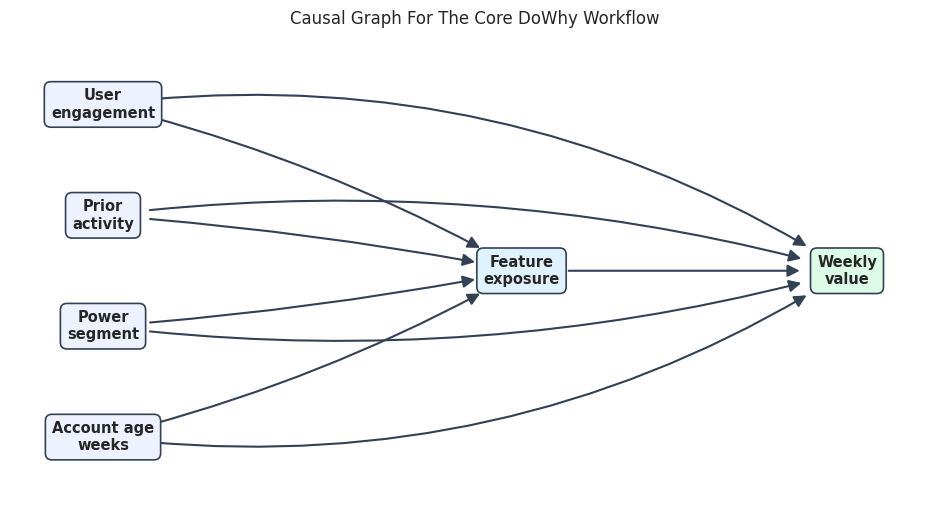

In [8]:
# Build and label the diagnostic visualization for the Visualize The Graph section.
graph_edges = [
    ("user_engagement", "feature_exposure"),
    ("user_engagement", "weekly_value"),
    ("prior_activity", "feature_exposure"),
    ("prior_activity", "weekly_value"),
    ("is_power_segment", "feature_exposure"),
    ("is_power_segment", "weekly_value"),
    ("account_age_weeks", "feature_exposure"),
    ("account_age_weeks", "weekly_value"),
    ("feature_exposure", "weekly_value"),
]
node_positions = {
    "user_engagement": (0.10, 0.88),
    "prior_activity": (0.10, 0.64),
    "is_power_segment": (0.10, 0.40),
    "account_age_weeks": (0.10, 0.16),
    "feature_exposure": (0.55, 0.52),
    "weekly_value": (0.90, 0.52),
}
node_labels = {
    "user_engagement": "User\nengagement",
    "prior_activity": "Prior\nactivity",
    "is_power_segment": "Power\nsegment",
    "account_age_weeks": "Account age\nweeks",
    "feature_exposure": "Feature\nexposure",
    "weekly_value": "Weekly\nvalue",
}
node_colors = {
    "user_engagement": "#eef2ff",
    "prior_activity": "#eef2ff",
    "is_power_segment": "#eef2ff",
    "account_age_weeks": "#eef2ff",
    "feature_exposure": "#e0f2fe",
    "weekly_value": "#dcfce7",
}
edge_radii = {
    ("user_engagement", "feature_exposure"): -0.07,
    ("prior_activity", "feature_exposure"): -0.03,
    ("is_power_segment", "feature_exposure"): 0.03,
    ("account_age_weeks", "feature_exposure"): 0.07,
    ("user_engagement", "weekly_value"): -0.18,
    ("prior_activity", "weekly_value"): -0.10,
    ("is_power_segment", "weekly_value"): 0.10,
    ("account_age_weeks", "weekly_value"): 0.18,
    ("feature_exposure", "weekly_value"): 0.00,
}
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_axis_off()
for source, target in graph_edges:
    ax.annotate(
        "",
        xy=node_positions[target],
        xytext=node_positions[source],
        arrowprops=dict(
            arrowstyle="-|>",
            color="#334155",
            linewidth=1.5,
            mutation_scale=18,
            shrinkA=34,
            shrinkB=34,
            connectionstyle=f"arc3,rad={edge_radii[(source, target)]}",
        ),
        zorder=1,
    )
for node, (x, y) in node_positions.items():
    ax.text(
        x,
        y,
        node_labels[node],
        ha="center",
        va="center",
        fontsize=10.5,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor=node_colors[node],
            edgecolor="#334155",
            linewidth=1.2,
        ),
        zorder=2,
    )
ax.set_title("Causal Graph For The Core DoWhy Workflow", pad=18)
fig.savefig(FIGURE_DIR / "01_core_workflow_dag.png", dpi=160, bbox_inches="tight")
plt.show()


The graph shows why adjustment is needed. There are backdoor paths from `feature_exposure` to `weekly_value` through the baseline variables. Blocking those paths is the identification task.


#### Create the DoWhy CausalModel

Now we create the `CausalModel`. This object contains the data, the treatment name, the outcome name, and the causal graph.

Notice that we drop `treatment_probability` because it was only a simulation diagnostic. The actual causal analysis uses variables that would plausibly exist in observed data.


In [9]:
model_data = analysis_df.drop(columns=["treatment_probability"]).copy()
model = CausalModel(
    data=model_data,
    treatment="feature_exposure",
    outcome="weekly_value",
    graph=causal_graph,
)
model_metadata = pd.DataFrame(
    [
        {"component": "treatment", "value": ", ".join(model._treatment)},
        {"component": "outcome", "value": ", ".join(model._outcome)},
        {"component": "common_causes", "value": ", ".join(model.get_common_causes())},
        {"component": "instruments", "value": ", ".join(model.get_instruments()) or "none detected"},
        {"component": "effect_modifiers", "value": ", ".join(model.get_effect_modifiers()) or "none detected"},
    ]
)
model_metadata.to_csv(TABLE_DIR / "01_causal_model_metadata.csv", index=False)
model_metadata


,component,value
0,treatment,feature_exposure
1,outcome,weekly_value
2,common_causes,"account_age_weeks, is_power_segment, prior_activity, user_engagement"
3,instruments,none detected
4,effect_modifiers,none detected


The model correctly detects the common causes from the graph. This is a useful checkpoint: if DoWhy detects a different set than you expected, inspect the graph before estimating anything.


### Identify the Causal Effect

Identification asks whether the graph supports a causal estimand using the observed variables. This is the step that separates causal reasoning from statistical estimation.

For this graph, we expect DoWhy to identify a backdoor adjustment estimand.


In [10]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)


Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                      ↪
──────────────────(E[weekly_value|account_age_weeks,is_power_segment,prior_act ↪
d[featureₑₓₚₒₛᵤᵣₑ]                                                             ↪

↪                        
↪ ivity,user_engagement])
↪                        
Estimand assumption 1, Unconfoundedness: If U→{feature_exposure} and U→weekly_value then P(weekly_value|feature_exposure,account_age_weeks,is_power_segment,prior_activity,user_engagement,U) = P(weekly_value|feature_exposure,account_age_weeks,is_power_segment,prior_activity,user_engagement)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



The printed result is deliberately explicit. The important part is the backdoor estimand and its unconfoundedness assumption: after conditioning on the observed common causes, there should be no unobserved common cause of treatment and outcome.


### Extract the Adjustment Set

The printed estimand is useful, but it is verbose. The code below creates a compact adjustment-set table that students can read alongside the graph.


In [11]:
adjustment_set = sorted(model.get_common_causes())
adjustment_table = pd.DataFrame(
    {
        "adjustment_variable": adjustment_set,
        "why_included": [
            "Pre-treatment common cause of feature exposure and weekly value"
            for _ in adjustment_set
        ],
    }
)
adjustment_table.to_csv(TABLE_DIR / "01_adjustment_set.csv", index=False)
adjustment_table


,adjustment_variable,why_included
0,account_age_weeks,Pre-treatment common cause of feature exposure and weekly value
1,is_power_segment,Pre-treatment common cause of feature exposure and weekly value
2,prior_activity,Pre-treatment common cause of feature exposure and weekly value
3,user_engagement,Pre-treatment common cause of feature exposure and weekly value


These are the variables DoWhy will use to block the backdoor paths in this example graph. If one of these variables were post-treatment, the graph would need to be reconsidered.


### Estimate the Effect with Linear Regression

Now that the estimand is identified, we can estimate it. The code below uses the DoWhy `backdoor.linear_regression` estimator.

The estimator is allowed to be ordinary regression because the causal work has already happened in the graph and identification step.


In [12]:
linear_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
)
print(linear_estimate)
print(f"DoWhy linear-regression estimate: {linear_estimate.value:.4f}")
print(f"Known true ATE: {TRUE_ATE:.4f}")


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                      ↪
──────────────────(E[weekly_value|account_age_weeks,is_power_segment,prior_act ↪
d[featureₑₓₚₒₛᵤᵣₑ]                                                             ↪

↪                        
↪ ivity,user_engagement])
↪                        
Estimand assumption 1, Unconfoundedness: If U→{feature_exposure} and U→weekly_value then P(weekly_value|feature_exposure,account_age_weeks,is_power_segment,prior_activity,user_engagement,U) = P(weekly_value|feature_exposure,account_age_weeks,is_power_segment,prior_activity,user_engagement)

## Realized estimand
b: weekly_value~feature_exposure+account_age_weeks+is_power_segment+prior_activity+user_engagement
Target units: ate

## Estimate
Mean value: 1.9768582400187293

DoWhy linear-regression estimate: 1.9769
Known

The DoWhy estimate should be close to the known true effect in this controlled example. The match happens because the graph is correct, all common causes are observed, and the outcome model is simple enough for linear adjustment.




#### Compare DoWhy with the Earlier Warm-Up

The code below places the naive estimate, plain adjusted regression, and DoWhy estimate in one table. The goal is to show that DoWhy formalizes the causal design around familiar statistical estimators.


In [13]:
core_estimate_comparison = pd.DataFrame(
    [
        {
            "quantity": "Known true ATE",
            "estimate": TRUE_ATE,
            "absolute_error_vs_true_ate": 0.0,
        },
        {
            "quantity": "Naive treated-minus-control difference",
            "estimate": naive_effect,
            "absolute_error_vs_true_ate": abs(naive_effect - TRUE_ATE),
        },
        {
            "quantity": "Plain adjusted OLS coefficient",
            "estimate": adjusted_effect,
            "absolute_error_vs_true_ate": abs(adjusted_effect - TRUE_ATE),
        },
        {
            "quantity": "DoWhy backdoor.linear_regression",
            "estimate": float(linear_estimate.value),
            "absolute_error_vs_true_ate": abs(float(linear_estimate.value) - TRUE_ATE),
        },
    ]
)
core_estimate_comparison.to_csv(TABLE_DIR / "01_core_estimate_comparison.csv", index=False)
core_estimate_comparison


,quantity,estimate,absolute_error_vs_true_ate
0,Known true ATE,2.000000,0.000000
1,Naive treated-minus-control difference,3.257946,1.257946
2,Plain adjusted OLS coefficient,1.976858,0.023142
3,DoWhy backdoor.linear_regression,1.976858,0.023142


The DoWhy regression estimate should align with the plain adjusted regression because both are estimating the same adjusted linear model. DoWhy's contribution is the explicit graph, estimand, and refutation workflow around that estimate.


#### Visualize the Estimate Comparison

A small plot makes the comparison easier to read. The dashed vertical line marks the known true effect from the data-generating process.


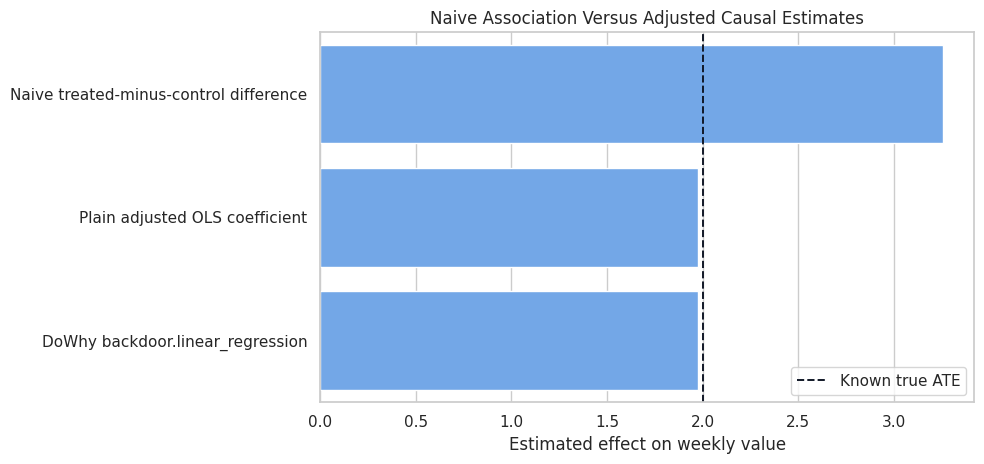

In [14]:
plot_df = core_estimate_comparison.query("quantity != 'Known true ATE'").copy()
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.barplot(
    data=plot_df,
    x="estimate",
    y="quantity",
    color="#60a5fa",
    ax=ax,
)
ax.axvline(TRUE_ATE, color="#111827", linestyle="--", linewidth=1.4, label="Known true ATE")
ax.set_title("Naive Association Versus Adjusted Causal Estimates")
ax.set_xlabel("Estimated effect on weekly value")
ax.set_ylabel("")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "01_core_estimate_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


The naive association sits farther from the true effect because it includes selection bias. The adjusted estimates move toward the true effect because they use the baseline common causes to make the comparison more like-for-like.




### Try Several Estimators for the Same Estimand

Once a causal effect is identified, we can estimate the same target with multiple statistical methods. This is a useful stability check.

Here we compare linear regression, propensity-score matching, propensity-score stratification, and propensity-score weighting.


In [15]:
estimator_specs = [
    ("linear_regression", "backdoor.linear_regression"),
    ("propensity_score_matching", "backdoor.propensity_score_matching"),
    ("propensity_score_stratification", "backdoor.propensity_score_stratification"),
    ("propensity_score_weighting", "backdoor.propensity_score_weighting"),
]
estimator_rows = []
for label, method_name in estimator_specs:
    try:
        estimate = model.estimate_effect(identified_estimand, method_name=method_name)
        estimator_rows.append(
            {
                "estimator": label,
                "method_name": method_name,
                "estimate": float(estimate.value),
                "absolute_error_vs_true_ate": abs(float(estimate.value) - TRUE_ATE),
                "status": "ok",
            }
        )
    except Exception as exc:
        estimator_rows.append(
            {
                "estimator": label,
                "method_name": method_name,
                "estimate": np.nan,
                "absolute_error_vs_true_ate": np.nan,
                "status": f"failed: {exc}",
            }
        )
estimator_comparison = pd.DataFrame(estimator_rows)
estimator_comparison.to_csv(TABLE_DIR / "01_estimator_comparison.csv", index=False)
estimator_comparison


,estimator,method_name,estimate,absolute_error_vs_true_ate,status
0,linear_regression,backdoor.linear_regression,1.976858,0.023142,ok
1,propensity_score_matching,backdoor.propensity_score_matching,1.946248,0.053752,ok
2,propensity_score_stratification,backdoor.propensity_score_stratification,1.981399,0.018601,ok
3,propensity_score_weighting,backdoor.propensity_score_weighting,2.033748,0.033748,ok


The estimates do not have to be identical. They use different modeling choices and finite-sample approximations. In this controlled setting, they should tell the same broad story: the effect is positive and close to the known true effect.




#### Plot Estimator Stability

This plot compares the estimator outputs to the known true effect. In real observational data, the true effect is unobserved. The same plot can still reveal whether estimators are broadly stable or sharply disagree.


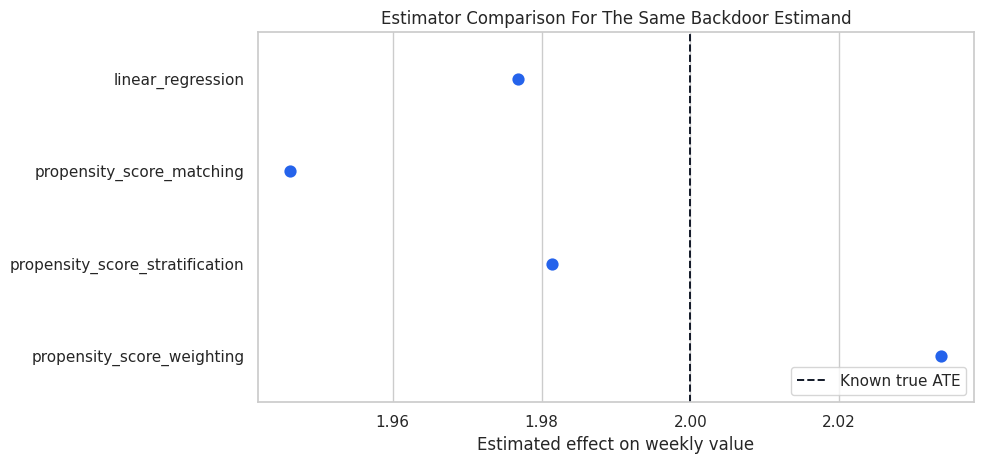

In [16]:
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.pointplot(
    data=estimator_comparison,
    x="estimate",
    y="estimator",
    linestyle="none",
    color="#2563eb",
    ax=ax,
)
ax.axvline(TRUE_ATE, color="#111827", linestyle="--", linewidth=1.4, label="Known true ATE")
ax.set_title("Estimator Comparison For The Same Backdoor Estimand")
ax.set_xlabel("Estimated effect on weekly value")
ax.set_ylabel("")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "01_estimator_stability.png", dpi=160, bbox_inches="tight")
plt.show()


Estimator agreement is encouraging but not a proof. All estimators can be wrong if the graph is wrong, if an important common cause is missing, or if the data lack overlap.


### Refutation Checks

A refuter asks whether the estimated effect behaves sensibly under a diagnostic perturbation. We use three basic refuters:

- **Placebo treatment:** replace the treatment with a fake randomized treatment.
- **Random common cause:** add an irrelevant random variable as a common cause.
- **Data subset:** re-estimate the effect on random subsets of the data.

Good refuter behavior It cannot prove the effect is correct. Bad behavior tells us to investigate.


In [17]:
# Define reusable helpers for the Refutation Checks section.
def scalar_or_nan(value):
    """
    Idea: Convert a one-element result to a float and use NaN when the value is unavailable.
    
    Parameters
    ----------
    value : object
        Numeric value being converted, formatted, or compared.
    
    Returns
    -------
    float
        Scalar float extracted from the input, or NaN when extraction is not possible.
    """
    try:
        return float(np.asarray(value).reshape(-1)[0])
    except Exception:
        return np.nan
refuter_specs = [
    (
        "placebo_treatment_refuter",
        {
            "method_name": "placebo_treatment_refuter",
            "placebo_type": "permute",
            "num_simulations": 20,
        },
        "The new effect should move toward zero when treatment is replaced by a fake treatment.",
    ),
    (
        "random_common_cause",
        {
            "method_name": "random_common_cause",
            "num_simulations": 20,
        },
        "Adding a random irrelevant common cause should not materially change the estimate.",
    ),
    (
        "data_subset_refuter",
        {
            "method_name": "data_subset_refuter",
            "subset_fraction": 0.80,
            "num_simulations": 20,
        },
        "Subsample estimates should remain in the same neighborhood as the original estimate.",
    ),
]
refuter_rows = []
for label, kwargs, expected_behavior in refuter_specs:
    refuter_result = model.refute_estimate(identified_estimand, linear_estimate, **kwargs)
    p_value = np.nan
    result_payload = getattr(refuter_result, "refutation_result", None)
    if isinstance(result_payload, dict):
        p_value = scalar_or_nan(result_payload.get("p_value"))
    refuter_rows.append(
        {
            "refuter": label,
            "estimated_effect": scalar_or_nan(refuter_result.estimated_effect),
            "new_effect": scalar_or_nan(refuter_result.new_effect),
            "effect_shift": scalar_or_nan(refuter_result.new_effect) - scalar_or_nan(refuter_result.estimated_effect),
            "p_value": p_value,
            "expected_behavior": expected_behavior,
        }
    )
refuter_summary = pd.DataFrame(refuter_rows)
refuter_summary.to_csv(TABLE_DIR / "01_refuter_summary.csv", index=False)
refuter_summary


,refuter,estimated_effect,new_effect,effect_shift,p_value,expected_behavior
0,placebo_treatment_refuter,1.976858,-0.006379,-1.983237,0.446312,The new effect should move toward zero when treatment is replaced by a fake treatment.
1,random_common_cause,1.976858,1.976882,0.000024,0.486216,Adding a random irrelevant common cause should not materially change the estimate.
2,data_subset_refuter,1.976858,1.977406,0.000548,0.492281,Subsample estimates should remain in the same neighborhood as the original estimate.


The placebo result should be near zero, while the random-common-cause and subset refuters should stay close to the original effect. These checks complement domain knowledge and create a habit of challenging estimates rather than simply reporting them.


### Refuter Results in Context

This plot shows the original effect next to the refuter-generated effects. It is a compact way to communicate whether the estimate survived basic stress tests.


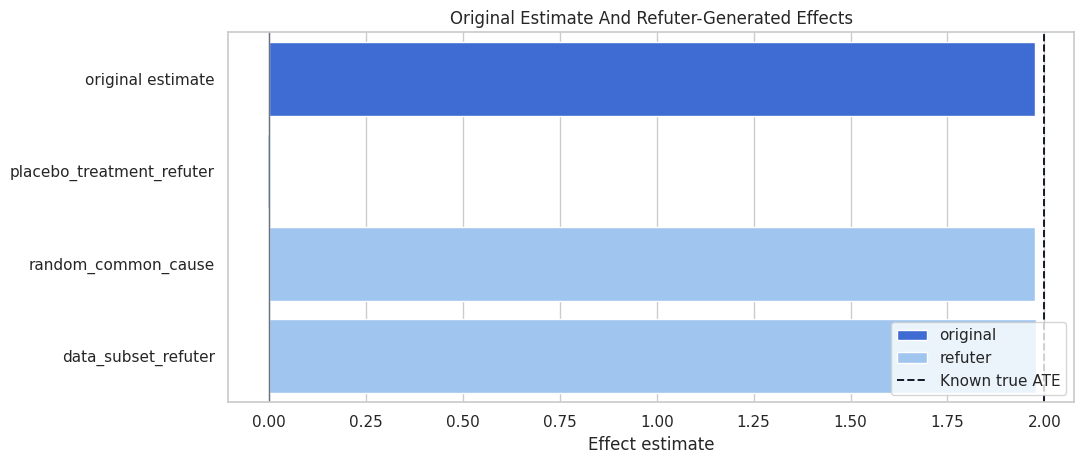

In [18]:
# Build and label the diagnostic visualization for the Refuter Results In Context section.
refuter_plot_df = pd.concat(
    [
        pd.DataFrame(
            [
                {
                    "label": "original estimate",
                    "effect": float(linear_estimate.value),
                    "type": "original",
                }
            ]
        ),
        refuter_summary.assign(label=refuter_summary["refuter"], effect=refuter_summary["new_effect"], type="refuter")[
            ["label", "effect", "type"]
        ],
    ],
    ignore_index=True,
)
fig, ax = plt.subplots(figsize=(11, 4.8))
sns.barplot(
    data=refuter_plot_df,
    x="effect",
    y="label",
    hue="type",
    dodge=False,
    palette={"original": "#2563eb", "refuter": "#93c5fd"},
    ax=ax,
)
ax.axvline(0, color="#6b7280", linewidth=1)
ax.axvline(TRUE_ATE, color="#111827", linestyle="--", linewidth=1.4, label="Known true ATE")
ax.set_title("Original Estimate And Refuter-Generated Effects")
ax.set_xlabel("Effect estimate")
ax.set_ylabel("")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "01_refuter_results.png", dpi=160, bbox_inches="tight")
plt.show()


The placebo row is the easiest to read: if the fake treatment still had a large effect, that would be worrying. The subset and random-common-cause rows help check whether the original estimate is brittle under small perturbations.




#### What DoWhy Adds Beyond a Regression

The code below writes a simple comparison between a plain regression workflow and a DoWhy workflow. This distinction is the core conceptual lesson of the lesson.


| workflow_component | plain_regression_workflow | dowhy_workflow |
| --- | --- | --- |
| Causal assumptions | Often implicit in the formula choice. | Written as a causal graph before estimation. |
| Identification | Usually skipped or described informally. | Explicit `identify_effect()` step returns an estimand and assumptions. |
| Estimation | Regression coefficient is the main output. | Estimator is chosen after the estimand is identified. |
| Robustness checks | Often added manually if time allows. | Refuters are part of the standard workflow. |
| Reporting | May over-focus on coefficient and p-value. | Should report graph assumptions, estimand, estimate, refuters, and limitations. |


DoWhy does not remove the need for judgment. It gives the analyst a structure for making judgment visible. That is especially important in observational work, where assumptions cannot be outsourced to an estimator.





## Reporting and Takeaways

### Final Causal Summary

A causal analysis should end with a short statement that separates the estimate from the assumptions. The code below creates a report-ready summary table.


In [19]:
final_summary = pd.DataFrame(
    [
        {
            "item": "Causal question",
            "summary": "Average effect of feature exposure on next-week user value.",
        },
        {
            "item": "Treatment",
            "summary": "feature_exposure",
        },
        {
            "item": "Outcome",
            "summary": "weekly_value",
        },
        {
            "item": "Main identifying assumption",
            "summary": "All common causes of exposure and weekly value are observed and adjusted for.",
        },
        {
            "item": "Identified strategy",
            "summary": "Backdoor adjustment using baseline engagement, activity, segment, and account age.",
        },
        {
            "item": "Primary estimate",
            "summary": f"{float(linear_estimate.value):.3f} additional weekly-value units from exposure.",
        },
        {
            "item": "Known simulation benchmark",
            "summary": f"The data were generated with a true effect of {TRUE_ATE:.3f}.",
        },
        {
            "item": "Refuter takeaway",
            "summary": "Placebo, random-common-cause, and subset checks behave as expected in this controlled example.",
        },
        {
            "item": "Main limitation",
            "summary": "The example is simulated and deliberately clean; real observational analyses require stronger data validation and domain review.",
        },
    ]
)
final_summary.to_csv(TABLE_DIR / "01_final_causal_summary.csv", index=False)
final_summary


,item,summary
0,Causal question,Average effect of feature exposure on next-week user value.
1,Treatment,feature_exposure
2,Outcome,weekly_value
3,Main identifying assumption,All common causes of exposure and weekly value are observed and adjusted for.
4,Identified strategy,"Backdoor adjustment using baseline engagement, activity, segment, and account age."
5,Primary estimate,1.977 additional weekly-value units from exposure.
6,Known simulation benchmark,The data were generated with a true effect of 2.000.
7,Refuter takeaway,"Placebo, random-common-cause, and subset checks behave as expected in this controlled example."
8,Main limitation,The example is simulated and clean by design; real observational analyses require stronger data validation and domain review.


This is the reporting pattern to carry forward: question, treatment, outcome, assumptions, identification strategy, estimate, diagnostics, and limitation. A causal result without its assumptions is only half a result.


### Student Exercises

To make the workflow stick, try these changes after running the lesson once:

1. Remove `user_engagement` from the graph and see how the estimate changes.
2. Increase the treatment assignment dependence on `user_engagement` and watch the naive bias grow.
3. Change the outcome noise scale and see which estimators become less stable.
4. Increase `num_simulations` in the refuters and compare runtime versus stability.
5. Rewrite the final summary in plain English for a non-technical stakeholder.


## Closing Notes

You have now walked through the core DoWhy workflow of modeling, identifying, estimating, and refuting. The sequence next spends more time on causal graphs and assumptions, because graph quality determines whether the identified estimand is meaningful.
